### load model output

In [31]:
import torch
import numpy as np
from zencell.zencell_model import models_vit
from zencell.zencell_model.cellpose.dynamics import compute_masks
import zarr
import dask.array as da

In [32]:

def load_model(checkpoint_path='/mnt/aperto/yin/zencell_ckpt/2D/checkpoint-499.pth'):
    """Load the vision transformer model"""
    model = models_vit.__dict__['vit_large_roipatch2x8x8_ctxpatch2x64x64_dep10_roi256_ctx1280_layerscale'](out_chans=3)
    model.half().eval().cuda()
    model.load_state_dict(torch.load(checkpoint_path, map_location="cpu", weights_only=False)["model"])
    print('Finish Load Model')
    return model

In [88]:
def run_inference(model, z, y, x, brain_path):
    """
    Run inference with the loaded model
    
    Args:
        model: The loaded vision transformer model
        input_data: Input numpy array with shape (B, 2, D, H, W)
                   where D=40, H=1280, W=1280
    
    Returns:
        Output numpy array with model predictions
    """
    # Convert numpy array to tensor if needed
    z=968
    y=5170
    x=1474

    brain_path = '/mnt/aperto/tatz_brain_data/240620_01_MX007-1/fused.zarr'
    zarr_file = zarr.open(brain_path, mode='r')
    za_wh = zarr_file['0']
    dask_wh = da.from_zarr(za_wh)

    print('shape is', dask_wh.shape)

    ref_slice = np.array(dask_wh[11][z:z+10, y:y+1280, x:x+1280])
    sig_slice = np.array(dask_wh[10][z:z+10, y:y+1280, x:x+1280])
    ref_tensor = torch.from_numpy(ref_slice) 
    sig_tensor = torch.from_numpy(sig_slice) 
    input_vol = torch.stack([ref_tensor, sig_tensor], dim=0).float()

    input_vol = input_vol - input_vol.mean(dim=(1, 2, 3), keepdim=True)
    input_vol = input_vol / (input_vol.std(dim=(1, 2, 3), keepdim=True) + 1e-6)
    input_vol = input_vol.half()
    input_tensor = input_vol.cuda()
   
   
    
    # Ensure batch dimension
    if input_tensor.dim() == 4:
        input_tensor = input_tensor.unsqueeze(0)
    
    print(f"Input tensor shape: {input_tensor.shape}")
    # Run inference
    with torch.no_grad():
        output = model(input_tensor)
    
    # Convert output to numpy
    output_np = output.cpu().float().numpy()
    
    return output_np


In [89]:
# Load the model
model = load_model(checkpoint_path='/mnt/aperto/yin/zencell_ckpt/2D/checkpoint-499.pth')

Finish Load Model


In [90]:


output = run_inference(model,z=1384, y=1851 ,x=1053,  brain_path = '/mnt/aperto/tatz_brain_data/240620_01_MX007-1/fused.zarr')
    
# Print output shape
print(f"Output shape: {output.shape}")  

shape is (12, 2784, 8685, 6251)
Input tensor shape: torch.Size([1, 2, 10, 1280, 1280])
Output shape: (1, 3, 10, 256, 256)


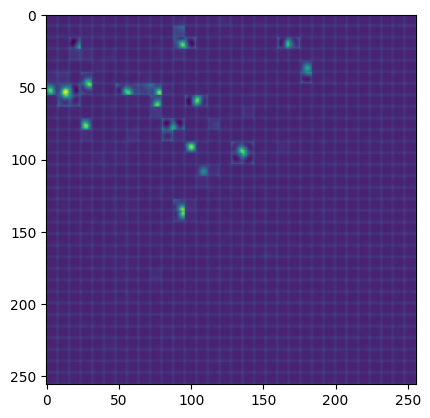

In [99]:
plt.imshow(output[0, 0, 4, :, :])

In [100]:
dP = np.zeros((2, 256, 256), dtype=np.float32)
dP[0] = output[0,1,4].astype(np.float32)
dP[1] = output[0,2,4].astype(np.float32)
cellprob =  output[0,0,4].astype(np.float32)

In [101]:
from cellpose import dynamics

cellmask_uptdate = dynamics.compute_masks(dP, cellprob, min_size=0, flow_threshold=None, cellprob_threshold = 0.1, do_3D=False)

In [102]:
cellmask_uptdate[0].shape

(256, 256)

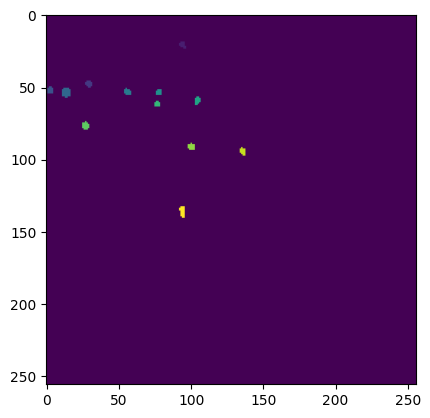

In [103]:
import matplotlib.pyplot as plt

plt.imshow(cellmask_uptdate[0])

In [50]:
cellmask_uptdate[1].shape

(2, 256, 256)

### load output

In [1]:
import numpy as np

In [8]:
output = np.load('/mnt/aperto/yin/MAE/inference_model/output.npy')

In [10]:
output.shape

(1, 4, 40, 256, 256)

In [18]:
dP = np.zeros((3, 40, 256, 256), dtype=np.float32)
dP[0] = output[0,1].astype(np.float32)
dP[1] = output[0,2].astype(np.float32)
dP[2] =  output[0,3].astype(np.float32)
cellprob =  output[0,0].astype(np.float32)

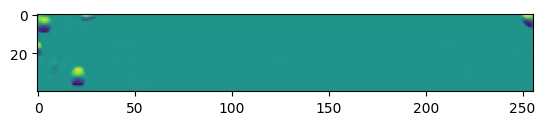

In [27]:
import matplotlib.pyplot as plt

plt.imshow(dP[0,:,100,:])

In [23]:
cellmask = cp_dynamics.compute_masks(dP, cellprob, min_size=0, flow_threshold=None, cellprob_threshold = 0.5, do_3D=True)

In [28]:
from cellpose import dynamics

cellmask_uptdate = dynamics.compute_masks(dP, cellprob, min_size=0, flow_threshold=None, cellprob_threshold = 0.5, do_3D=True)

In [32]:
len(cellmask_uptdate)

2

In [38]:
from napari_cellseg3d.code_models.models.zencell.cellpose.dynamics import (
    compute_masks,
)

prob1 = np.load('/mnt/aperto/yin/napari_cellseg/napari_cellseg3d/code_models/models/zencell/output/sig1_ref3_z1200_y4000_x3000_cell_prob.npy')
flow1 = np.load('/mnt/aperto/yin/napari_cellseg/napari_cellseg3d/code_models/models/zencell/output/sig1_ref3_z1200_y4000_x3000_cell_flow.npy')

In [39]:

cellmask_uptdate = compute_masks(flow1, prob1, min_size=0, flow_threshold=None, cellprob_threshold = 0.5, do_3D=True)

In [ ]:
cellmask_uptdate[0]

array([[[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       ...,

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0]],

       [[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        ...,
        [0, 0, 0, ..., 

In [ ]:
import napari

viewer = napari.Viewer()
viewer.add_labels(cellmask_uptdate[0], blending='additive')
#viewer.add_image(flow1)
# viewer.add_image(prob2)
# viewer.add_image(flow2)

TypeError: Only integer types are supported for Labels layers, but data contains float32.

In [22]:
z,y,x =prob.shape

In [2]:
import napari

viewer = napari.Viewer()          
viewer.open(
    "/mnt/aperto/tatz_brain_data/240620_01_MX007-1/fused.zarr",
    plugin="napari-ome-zarr",
    lazy=True,          
)
napari.run()     


In [1]:
import napari

viewer = napari.Viewer()
viewer.open("https://uk1s3.embassy.ebi.ac.uk/idr/zarr/v0.4/idr0101A/13457537.zarr", plugin="napari-ome-zarr")

napari.run()

/mnt/aperto/anaconda/envs/zen_sam/lib/python3.12/site-packages/napari/utils/colormaps/colormap.py:435: UserWarning: color_dict did not provide a default color. Missing keys will be transparent. To provide a default color, use the key `None`, or provide a defaultdict instance.
  warn(


In [ ]:
from ome_zarr.io import parse_url        
from ome_zarr.reader import Reader       # NGFF 官方 Reader
import napari                            # 只是用来验证结果

path = "/mnt/aperto/tatz_brain_data/240620_01_MX007-1/fused.zarr"

loc = parse_url(path, mode="r")          # mode="r" 只读，避免误写

reader = Reader(loc)

# ③ 把所有 Node 拉成列表（只迭代一次即可）
nodes = list(reader())                   # 每个 Node 对应一段数据或元信息

# ④ 找到第一个 multiscale 图像节点
img_node = nodes[0]                      # 通常第 0 个就是图像像素

# ⑤ 拿到实际数据（Dask Array 或列表[每层]）
pyramid = img_node.data                  # 有金字塔时是 list[dask.array]；否则直接 dask.array
fullres = pyramid[0] if isinstance(pyramid, list) else pyramid



In [6]:
meta_dict = img_node.metadata

In [22]:
print('axes: ', meta_dict['axes'][0]['name'], meta_dict['axes'][1]['name'], meta_dict['axes'][2]['name'], meta_dict['axes'][3]['name'])

axes:  c z y x


In [29]:
len(meta_dict['axes'])

4

In [27]:
print('scale 0:',meta_dict['coordinateTransformations'][0][0]['scale'],'\n',
    'scale 1:',meta_dict['coordinateTransformations'][1][0]['scale'],'\n',
        'scale 2:',meta_dict['coordinateTransformations'][2][0]['scale'],'\n',
        'scale 3:',meta_dict['coordinateTransformations'][3][0]['scale'],'\n',
        'scale 4:',meta_dict['coordinateTransformations'][4][0]['scale'],
    
      
      )

scale 0: [1.0, 2.0, 1.3, 1.3] 
 scale 1: [1.0, 4.0, 2.6, 2.6] 
 scale 2: [1.0, 8.0, 5.2, 5.2] 
 scale 3: [1.0, 16.0, 10.4, 10.4] 
 scale 4: [1.0, 32.0, 20.8, 20.8]


In [40]:
fullres


dask.array<from-zarr, shape=(12, 2784, 8685, 6251), dtype=uint16, chunksize=(1, 256, 256, 256), chunktype=numpy.ndarray>

In [60]:
pyramid[0].shape

(12, 2784, 8685, 6251)

In [50]:


import dask.array as da


arr = pyramid[4]
n_elements = arr.size 

bytes_per_element = arr.dtype.itemsize  # uint16 is 2 bytes

# Total Bytes
total_bytes = n_elements * bytes_per_element

# To TiB
total_tib = total_bytes / (1024**4)

print(f"Total Bytes: {total_bytes}")
print(f"Total TiB: {total_tib:.6f} TiB")


Total Bytes: 886619088
Total TiB: 0.000806 TiB


In [33]:
import numpy as np
img = np.load('/mnt/aperto/yin/cell_annotation/3D_positive_all/0007_img.npy')
voxel_size = (2.0,1.3,1.3)

In [35]:
import napari

viewer = napari.Viewer()
viewer.add_image(img, channel_axis=0, contrast_limits=[0,65535])

[<Image layer 'Image' at 0x7783b5273370>,
 <Image layer 'Image [1]' at 0x7783b5270100>]

### customize input size

In [62]:
import tifffile
import os

In [92]:
corner = [1227, 870, 3137]
plane_position = 61
crop_size = [100, 256,256]
img_size = [10, 500, 500]
label_root = '/mnt/aperto/tatz_brain_data/anno_241011/train'
img_id = '0006'

In [93]:
label_vol_st = (corner[0] + plane_position, corner[1], corner[2])
label_vol_ed = (corner[0] + plane_position + 1, corner[1] + crop_size[1], corner[2] + crop_size[2])
label_vol = [tifffile.imread(os.path.join(label_root, f"{img_id}_mask.tif"))]



label_vol = np.stack(label_vol, axis=0)

assert label_vol.shape == tuple(y - x for x, y in zip(label_vol_st, label_vol_ed))



In [94]:

label_mask = np.ones_like(label_vol, dtype=bool)

slice_arr = []
pad_arr = []
new_label_vol_st, new_label_vol_ed = [], []
for dim in range(3):
    if label_vol.shape[dim] <= img_size[dim]:
        slice_arr.append(slice(0, label_vol.shape[dim], 1))
        tot_pad = img_size[dim] - label_vol.shape[dim]
        pad_arr.append((tot_pad // 2, (tot_pad + 1) // 2))
        new_label_vol_st.append(label_vol_st[dim] - tot_pad // 2)
        new_label_vol_ed.append(label_vol_ed[dim] + (tot_pad + 1) // 2)
    else:
        tot_slice = label_vol.shape[dim] - img_size[dim]
        slice_arr.append(slice(tot_slice // 2, label_vol.shape[dim] - (tot_slice + 1) // 2, 1))
        pad_arr.append((0, 0))
        new_label_vol_st.append(label_vol_st[dim] + tot_slice // 2)
        new_label_vol_ed.append(label_vol_ed[dim] - (tot_slice + 1) // 2)
label_vol_st = tuple(new_label_vol_st)
label_vol_ed = tuple(new_label_vol_ed)
label_vol, label_mask = label_vol[tuple(slice_arr)], label_mask[tuple(slice_arr)]
label_vol, label_mask = np.pad(label_vol, pad_arr), np.pad(label_mask, pad_arr)


assert label_vol.shape == label_mask.shape and label_vol.shape == tuple(y - x for x, y in zip(label_vol_st, label_vol_ed))
img_slice_arr, img_pad_arr = [], []

In [102]:
np.unique(label_vol)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20], dtype=uint8)

In [104]:
label_mask.shape

(10, 500, 500)

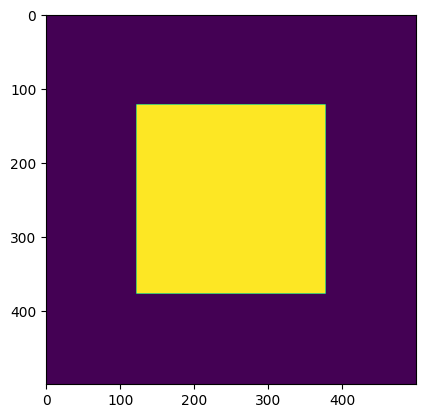

In [105]:
import matplotlib.pyplot as plt
plt.imshow(label_mask[4])

In [96]:
print('ori label start and end:', label_vol_st, label_vol_ed)

ori label start and end: (1284, 748, 3015) (1294, 1248, 3515)


In [75]:
corner = [1227, 870, 3137]

In [72]:
label_vol_st

(1284, 742, 3009)

In [74]:
label_vol_ed

(1294, 1254, 3521)

In [110]:
1000 // 256* 256 + 256

1024

In [112]:
100 //256

0

In [116]:
768// (2*2**3)

48

In [139]:
brain_path = '/mnt/aperto/tatz_brain_data/240620_01_MX007-1/fused.zarr'

In [146]:
whloe_block = zarr.open(brain_path, mode='r')
za_wh = whloe_block['3']
za_wh.shape

(12, 348, 1086, 782)

In [156]:
whloe_block_np = za_wh[1][150:190]

In [157]:
# whole_mean  = whloe_block_np.mean()
# whole_std = whloe_block_np.std()
# print('mean:', whole_mean, 'std:', whole_std)

In [158]:
whole_min  = whloe_block_np.min()
whole_max = whloe_block_np.max()
print('min:', whole_min, 'max:', whole_max)

min: 0 max: 56746


In [159]:
whloe_block_norm = (whloe_block_np - whole_min) / (whole_max - whole_min)

In [160]:
whole_norm_small = whloe_block_norm[:, 400-128:400+128, 0:65+128]

In [161]:
np.save('/mnt/aperto/yin/zencell_plugin/src/zencell/zencell_model/whole_norm_1_minmax.npy', whloe_block_norm)
np.save('/mnt/aperto/yin/zencell_plugin/src/zencell/zencell_model/whole_norm_small_1_minmax.npy', whole_norm_small)

In [165]:

all_points = {6: {'point': [135.        , 573.08771607, 422.91384174], 'vis_z': 40, 'vis_y': 768, 'vis_x': 768, 'seg_y': 256, 'seg_x': 256}
            ,1: {'point': [135.        , 550.26107991, 144.42888064], 'vis_z': 51, 'vis_y': 555, 'vis_x': 768, 'seg_y': 100, 'seg_x': 256}
               }

In [167]:
for idx in all_points:
    point_info = all_points[idx]
    point = point_info['point']
    vis_z = point_info['vis_z']
    vis_y = point_info['vis_y']
    vis_x = point_info['vis_x']
    seg_y = point_info['seg_y']
    seg_x = point_info['seg_x']
    print(f"Point {idx}: {point}, vis_z: {vis_z}, vis_y: {vis_y}, vis_x: {vis_x}, seg_y: {seg_y}, seg_x: {seg_x}")

Point 6: [135.0, 573.08771607, 422.91384174], vis_z: 40, vis_y: 768, vis_x: 768, seg_y: 256, seg_x: 256
Point 1: [135.0, 550.26107991, 144.42888064], vis_z: 51, vis_y: 555, vis_x: 768, seg_y: 100, seg_x: 256


In [171]:
all_points = {}

In [173]:
if not all_points:
    print("all_points is empty")

all_points is empty


In [ ]:


segment_plane = np.zeros_like((vis_y, vis_x))

In [2]:
import numpy as np
flow = np.load('/mnt/aperto/yin/zencell_plugin/mae_3d_sig1_ref3_z1384_y5330_x5264_flow.npy')
mask = np.load('/mnt/aperto/yin/zencell_plugin/mae_3d_sig1_ref3_z1384_y5330_x5264_mask.npy')

In [4]:
import napari
viewer = napari.Viewer()
viewer.add_image(flow, name='flow', blending='additive')
viewer.add_labels(mask, name='mask', blending='additive')

<Labels layer 'mask' at 0x70da9c3b6e30>

In [8]:
zarr_path = '/mnt/aperto/tatz_brain_data/240620_01_MX007-1/fused.zarr'
import zarr
zarr_file = zarr.open(zarr_path, mode='r')["0"]


In [13]:
slice = zarr_file[1, 1384-40:1384+40, 5744-256:5744+256, 1032-256:1032+256]

In [16]:
import numpy as np
np.save('/mnt/aperto/yin/zencell_plugin/img_sig1_z1384_y5744_x1032_slice.npy', slice)

In [3]:
idx = 1
z_center = 1384
seg_patch_y = 256
seg_patch_x = 256
saving_path = f'{idx}_MAE_pseudo_{z_center}_{seg_patch_y}_{seg_patch_x}'

In [6]:
saving_path.split('_')[-3]

'1384'

In [25]:
import zarr
import dask.array as da

zarr_file = zarr.open('/mnt/aperto/tatz_brain_data/240620_01_MX007-1/fused.zarr', mode='r')
resolution = list(zarr_file.keys())
za_wh = zarr_file['0']
dask_wh = da.from_zarr(za_wh)

In [26]:
dask_wh.shape

(12, 2784, 8685, 6251)

In [41]:
cropimg = dask_wh[2][1391, 4074-128:4074+128, 1978-128:1978+128]


In [42]:
import tifffile as tf
img = tf.imread('/mnt/aperto/yin/zencell_plugin/z_1036/0_combined_segmentation_image.tif')

In [43]:
import numpy as np
np.unique(img[1] == cropimg.compute())

array([ True])

### crop a 3D dense area for test

In [6]:
import zarr
import dask.array as da
zarr_path = '/mnt/aperto/tatz_brain_data/240620_01_MX007-1/fused.zarr'
sig_chn = 2
zarr_file = zarr.open(zarr_path, mode='r')
za_wh = zarr_file['0']
dask_wh = da.from_zarr(za_wh)
coord = [1388, 4581 , 442]


In [13]:
block1 = dask_wh[sig_chn][coord[0]-20:coord[0]+20, coord[1]-128:coord[1]+128, coord[2]-128:coord[2]+128]

In [14]:
import numpy as np  
np.save('/mnt/aperto/yin/zencell_plugin/debug_2d/dense_block/0001.npy', block1)
#np.save('/mnt/aperto/yin/zencell_plugin/debug_2d/dense_2d/0001_2d.npy', block1[20])

In [2]:
import napari
import numpy as np
import tifffile as tf

viewer = napari.Viewer()

#label_mae_1 = np.load('/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z0160.npy')[5448-128:5448+128,3655-128:3655+128]
#label_mae_0 = np.load('/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z0160.npy')[4566-128:4566+128,2224-128:2224+128]
#label_mae_0 = np.load('/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z0461.npy')[3953-64:3953+64,1948-64:1948+64] 
#label_mae_1 = np.load('/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z0461.npy')[4087-64:4087+64,4721-64:4721+64]

#label_mae_0 = np.load('/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z0704.npy')[4508-128:4508+128,540-128:540+128]

#label_mae_1 = np.load('/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z0704.npy')[5366-128:5366+128,1375-128:1375+128] # 5366, 1375
#label_mae_2 = np.load('/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z0704.npy')[5522-128:5522+128,967-128:967+128]

label = tf.imread('/mnt/aperto/yin/data/tatz_annotation/dense_2d/tmsegment/res_z0160/0_combined_segmentation.tif')
img = tf.imread('/mnt/aperto/yin/data/tatz_annotation/dense_2d/tmsegment/res_z0160/0_combined_segmentation_image.tif')
viewer.add_image(img, name='image', blending='additive')
viewer.add_labels(label, name='label', blending='additive')
#viewer.add_labels(label_mae_2, name='label_mae_1', blending='additive')

<Labels layer 'label' at 0x7b79c23104d0>

In [6]:
import napari
import numpy as np
import tifffile as tf

viewer = napari.Viewer()

label = np.load('/mnt/aperto/yin/zencell_plugin/combined_res.npy')
viewer.add_labels(label, name='label', blending='additive')

<Labels layer 'label' at 0x7b79ad699350>

In [7]:
np.unique(label)

array([  0,   1,   2,   3,   4,   5,   7,   8,   9,  10,  11,  12,  13,
        14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,
        27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,
        40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,
        53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  86,  87,  88,  89,  91,  93,  94,
        95,  96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107,
       108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120,
       121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133,
       134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146,
       147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159,
       160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172,
       173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 18

In [1]:
import napari
import numpy as np

img = np.load('/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z0160_img.npy')
label_ori = np.load('/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z0160.npy')
label_new = np.load('/mnt/aperto/yin/whole_plane_output.240620_02_MX007-1.ref3_sig2/plane_160.npy')



In [2]:
plane_list = [1036, 160, 1956, 461, 704]

for plane in plane_list:
    img = np.load(f'/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z{plane:04d}_img.npy')
    label_ori = np.load(f'/mnt/aperto/yin/whole_brain_output.240620_02_MX007_1/chn2_z{plane:04d}.npy')
    label_new = np.load(f'/mnt/aperto/yin/whole_plane_output.240620_02_MX007-1.ref3_sig2/plane_{plane}.npy')


    viewer = napari.Viewer()
    viewer.add_image(img, name='image', blending='additive', contrast_limits=[0, 65535])
    viewer.add_labels(label_ori, name='label_ori', blending='additive')
    viewer.add_labels(label_new, name='label_new', blending='additive')
    viewer.show(block=True)

In [6]:
import tifffile
viewer = napari.Viewer()
label = tifffile.imread('/mnt/aperto/yin/zencell_plugin/z_1040/0_combined_res.tif')
image = tifffile.imread('/mnt/aperto/yin/zencell_plugin/z_1040/0_combined_res_image.tif')
viewer.add_labels(label, name='label', blending='additive')
viewer.add_image(image, name='image', blending='additive', contrast_limits=[0, 65535])
napari.run()

In [10]:
import pandas as pd
df = pd.read_csv('/mnt/aperto/yin/zencell_plugin/meta_info/current_points.csv')

In [12]:
df

,id,point,vis_z,vis_y,vis_x,seg_y,seg_x,ref_chn,sig_chn,brain_path
0,0,"[1391, 4603, 2324]",40,768,768,256,256,3,2,/mnt/aperto/tatz_brain_data/240620_01_MX007-1/...


In [15]:
import zarr
import dask.array as da

zarr_path = '/mnt/aperto/tatz_brain_data/240620_01_MX007-1/fused.zarr'
sig_chn = 2
zarr_file = zarr.open(zarr_path, mode='r')
za_wh = zarr_file['0']
dask_wh = da.from_zarr(za_wh)
coord = [1391, 4603 , 2324]

block1 = dask_wh[sig_chn][coord[0]-20:coord[0]+20, coord[1]-128:coord[1]+128, coord[2]-128:coord[2]+128].compute()  

In [17]:
np.unique(block1[20] == image[1])


array([ True])